# Session 9, Notebook 2: The Black-Scholes PDE with a PINN

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 15:10-16:00, Physics-informed neural networks: applications and hands-on
**Slides:** `09_PINNs_Applications.pdf`
**Notebook role:** self-study
**Author:** Simon Scheidegger (HEC, University of Lausanne)

Option pricing is the canonical PDE problem in finance. Black-Scholes is stylised, but it is the
frame more realistic models are built on, and it has a closed form, so the error of the network can
be measured exactly. Two things make it a good PINN target: the solver is mesh-free, so the same code
carries over to pricing problems with more state variables, and since the network is differentiated
by autograd anyway, the Greeks come out of the same object at no extra cost.

For a European call with value $V(S,t)$,

$$\frac{\partial V}{\partial t} + \tfrac12 \sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
  + r S \frac{\partial V}{\partial S} - r V = 0,$$

with the terminal condition $V(S,T) = \max(S-K, 0)$, $V(0,t) = 0$, and
$V(S_{\max}, t) = S_{\max} - K e^{-r(T-t)}$ at the far end of the price domain.

| Section | Content |
|:--|:--|
| 1 | Network, residual, samplers |
| 2 | Training: Adam on resampled points, then L-BFGS on a fixed design, in double precision |
| 3 | The price against the closed form, and where the error sits |
| 4 | The Greeks by automatic differentiation |

In [1]:
SEED = 42

In [2]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(SEED); np.random.seed(SEED)
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                     "legend.fontsize": 9, "font.family": "serif", "mathtext.fontset": "cm",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_TRUE, C_SOFT, C_HARD = "#264653", "#e76f51", "#2a9d8f"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = True   # the stored run writes the figures the slides use
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")
from scipy.stats import norm

r, sigma, K, T, S_max = 0.05, 0.2, 50.0, 1.0, 100.0

## 1. Network, residual, samplers

Inputs are mapped to $[-1,1]$ and the output is multiplied by the strike, so the network works in
units of order one. Three hidden layers of 64 `tanh` units. The residual needs $V_t$, $V_S$ and
$V_{SS}$, three calls to `torch.autograd.grad`.

In [3]:
class PINN(nn.Module):
    def __init__(self, widths=(2, 64, 64, 64, 1)):
        super().__init__()
        layers = []
        for i in range(len(widths) - 2):
            layers += [nn.Linear(widths[i], widths[i + 1]), nn.Tanh()]
        layers += [nn.Linear(widths[-2], widths[-1])]
        self.net = nn.Sequential(*layers)
    def forward(self, S, t):
        x = torch.cat([2.0 * S / S_max - 1.0, 2.0 * t / T - 1.0], dim=1)
        return K * self.net(x)

def pde_residual(model, S, t):
    S = S.clone().requires_grad_(True); t = t.clone().requires_grad_(True)
    V = model(S, t)
    ones = torch.ones_like(V)
    V_t = torch.autograd.grad(V, t, grad_outputs=ones, create_graph=True)[0]
    V_S = torch.autograd.grad(V, S, grad_outputs=ones, create_graph=True)[0]
    V_SS = torch.autograd.grad(V_S, S, grad_outputs=ones, create_graph=True)[0]
    return V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V

def sample(n_int, n_bc, n_term):
    """Interior points, the S = 0 and S = S_max boundaries, and the terminal line t = T."""
    S_int, t_int = torch.rand(n_int, 1) * S_max, torch.rand(n_int, 1) * T
    t_bc = torch.rand(n_bc, 1) * T
    S_term = torch.rand(n_term, 1) * S_max
    return S_int, t_int, t_bc, S_term

model = PINN()
print(model)

PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 2. Training

Four loss terms, all divided by the strike so that they are comparable: the PDE residual, the two
price boundaries, and the terminal payoff, weighted 10 because the kink at $S = K$ is the hard part.
Adam on freshly sampled points for 2,500 steps, then L-BFGS on one fixed design in double precision.

In [4]:
terminal_weight = 10.0

def loss_terms(batch):
    S_int, t_int, t_bc, S_term = batch
    mse_pde = torch.mean((pde_residual(model, S_int, t_int) / K) ** 2)
    mse_bc0 = torch.mean((model(torch.zeros_like(t_bc), t_bc) / K) ** 2)
    V_far = model(torch.full_like(t_bc, S_max), t_bc)
    mse_far = torch.mean(((V_far - (S_max - K * torch.exp(-r * (T - t_bc)))) / K) ** 2)
    V_term = model(S_term, torch.full_like(S_term, T))
    mse_term = torch.mean(((V_term - torch.relu(S_term - K)) / K) ** 2)
    return mse_pde + mse_bc0 + mse_far + terminal_weight * mse_term, mse_pde, mse_term

n_adam = 2500
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[1200, 2000], gamma=0.4)
t0 = time.time()
for step in range(1, n_adam + 1):
    loss, mse_pde, mse_term = loss_terms(sample(1000, 256, 512))
    optimizer.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 50.0)
    optimizer.step(); scheduler.step()
    if step % 500 == 0 or step == 1:
        print(f"Adam {step:5d}  loss {loss.item():.3e}  (PDE {mse_pde.item():.2e}, terminal {mse_term.item():.2e})")
print(f"Adam stage: {time.time() - t0:.0f} s")

fixed_batch = sample(2048, 512, 1024)
lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=300, history_size=50,
                          tolerance_grad=1e-12, tolerance_change=1e-14, line_search_fn="strong_wolfe")
n_eval = [0]
def closure():
    lbfgs.zero_grad(); loss, mse_pde, mse_term = loss_terms(fixed_batch); loss.backward(); n_eval[0] += 1
    if n_eval[0] % 100 == 0:
        print(f"L-BFGS eval {n_eval[0]:4d}  loss {loss.item():.3e}  (PDE {mse_pde.item():.2e}, terminal {mse_term.item():.2e})")
    return loss
t0 = time.time(); lbfgs.step(closure)
final_loss = loss_terms(fixed_batch)[0].item()
print(f"L-BFGS stage: {n_eval[0]} evaluations, {time.time() - t0:.0f} s, final loss {final_loss:.3e}")

Adam     1  loss 2.047e+00  (PDE 4.75e-03, terminal 1.29e-01)


Adam   500  loss 5.435e-03  (PDE 1.57e-03, terminal 3.39e-04)


Adam  1000  loss 8.892e-04  (PDE 2.13e-04, terminal 6.61e-05)


Adam  1500  loss 5.616e-04  (PDE 1.75e-04, terminal 3.73e-05)


Adam  2000  loss 4.418e-04  (PDE 1.35e-04, terminal 2.97e-05)


Adam  2500  loss 4.003e-04  (PDE 1.26e-04, terminal 2.64e-05)
Adam stage: 39 s


L-BFGS eval  100  loss 1.355e-04  (PDE 4.18e-05, terminal 8.72e-06)


L-BFGS eval  200  loss 7.745e-05  (PDE 3.72e-05, terminal 3.90e-06)


L-BFGS eval  300  loss 5.383e-05  (PDE 2.77e-05, terminal 2.54e-06)


L-BFGS stage: 324 evaluations, 11 s, final loss 5.228e-05


## 3. The price against the closed form

$$C(S,t) = S\,\Phi(d_1) - K e^{-r(T-t)}\,\Phi(d_2), \qquad
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}, \quad d_2 = d_1 - \sigma\sqrt{T-t}.$$

The comparison is at $t = 0$, one year to maturity, over the whole price range.

at t = 0: max |error| 0.060 at S = 66.2, mean |error| 0.029
at the money, S = K: closed form 5.225, PINN 5.241


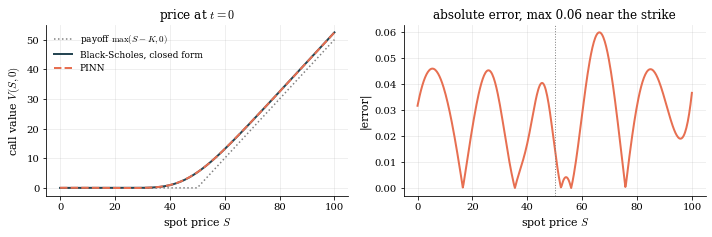

In [5]:
def bs_call(S, tau):
    S = np.asarray(S, dtype=float); C = np.zeros_like(S); m = S > 0
    d1 = (np.log(S[m] / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau)); d2 = d1 - sigma * np.sqrt(tau)
    C[m] = S[m] * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    return C

S_np = np.linspace(0, S_max, 401)
S_te = torch.tensor(S_np).reshape(-1, 1); t_te = torch.zeros_like(S_te)
with torch.no_grad():
    V_pinn = model(S_te, t_te).numpy().ravel()
V_bs = bs_call(S_np, T)
err = np.abs(V_pinn - V_bs)
i_max = err.argmax()
print(f"at t = 0: max |error| {err.max():.3f} at S = {S_np[i_max]:.1f}, mean |error| {err.mean():.3f}")
print(f"at the money, S = K: closed form {bs_call([K], T)[0]:.3f}, PINN {V_pinn[np.argmin(np.abs(S_np - K))]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(S_np, np.maximum(S_np - K, 0), ":", color="gray", lw=1.5, label="payoff $\\max(S-K,0)$")
axes[0].plot(S_np, V_bs, color=C_TRUE, lw=2, label="Black-Scholes, closed form")
axes[0].plot(S_np, V_pinn, "--", color=C_SOFT, lw=2, label="PINN")
axes[0].set_xlabel("spot price $S$"); axes[0].set_ylabel("call value $V(S,0)$"); axes[0].legend(frameon=False); axes[0].set_title("price at $t=0$")
axes[1].plot(S_np, err, color=C_SOFT, lw=2); axes[1].axvline(K, color="gray", ls=":", lw=1)
axes[1].set_xlabel("spot price $S$"); axes[1].set_ylabel("|error|"); axes[1].set_title(f"absolute error, max {err.max():.2f} near the strike")
fig.tight_layout(); savefig(fig, "pinn_bs_price"); plt.show()

## 4. The Greeks by automatic differentiation

Delta $= V_S$ and Gamma $= V_{SS}$ are the first and second derivative of the network, the same
calls the residual already used. No bumping, no re-solving. Gamma is the demanding one: it is a
second derivative of a network trained on a residual that itself contains $V_{SS}$, and it shows
where the fit is only accurate to first order.

Delta: max |error| 0.009   Gamma: max |error| 0.0030 (Gamma peaks at 0.0437)


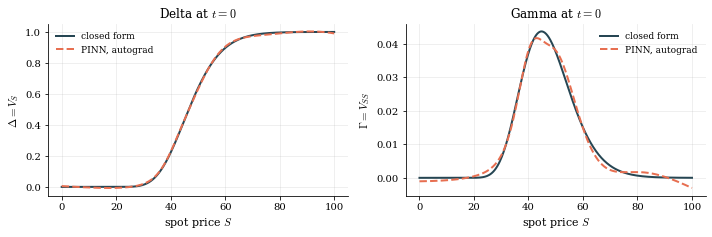

In [6]:
S_g = torch.tensor(S_np).reshape(-1, 1).requires_grad_(True); t_g = torch.zeros_like(S_g)
V_g = model(S_g, t_g)
delta = torch.autograd.grad(V_g, S_g, grad_outputs=torch.ones_like(V_g), create_graph=True)[0]
gamma = torch.autograd.grad(delta, S_g, grad_outputs=torch.ones_like(delta))[0]
delta_np, gamma_np = delta.detach().numpy().ravel(), gamma.detach().numpy().ravel()

m = S_np > 0; d1 = np.zeros_like(S_np); d1[m] = (np.log(S_np[m] / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
delta_bs = np.where(m, norm.cdf(d1), 0.0)
gamma_bs = np.zeros_like(S_np); gamma_bs[m] = norm.pdf(d1[m]) / (S_np[m] * sigma * np.sqrt(T))
print(f"Delta: max |error| {np.abs(delta_np - delta_bs).max():.3f}   Gamma: max |error| {np.abs(gamma_np - gamma_bs).max():.4f} (Gamma peaks at {gamma_bs.max():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(S_np, delta_bs, color=C_TRUE, lw=2, label="closed form"); axes[0].plot(S_np, delta_np, "--", color=C_SOFT, lw=2, label="PINN, autograd")
axes[0].set_xlabel("spot price $S$"); axes[0].set_ylabel(r"$\Delta = V_S$"); axes[0].legend(frameon=False); axes[0].set_title("Delta at $t=0$")
axes[1].plot(S_np, gamma_bs, color=C_TRUE, lw=2, label="closed form"); axes[1].plot(S_np, gamma_np, "--", color=C_SOFT, lw=2, label="PINN, autograd")
axes[1].set_xlabel("spot price $S$"); axes[1].set_ylabel(r"$\Gamma = V_{SS}$"); axes[1].legend(frameon=False); axes[1].set_title("Gamma at $t=0$")
fig.tight_layout(); savefig(fig, "pinn_bs_greeks"); plt.show()

## Summary

* At $t = 0$ the PINN price is within 0.06 of the closed form everywhere on $[0, 100]$ (mean error
  0.03), and at the money it gives 5.24 against 5.23. The largest error sits above the strike,
  where the terminal payoff has its kink.
* Delta comes out of the same network to within 0.01; Gamma, a second derivative, to within
  0.003 of a peak of 0.044. No bumping, no re-solve.
* Four loss terms of different origin (PDE, two boundaries, terminal payoff) are the situation the
  loss-balancing session warned about. Here they are kept comparable by dividing every term by the
  strike and weighting the terminal condition by 10. A hard trial solution for the terminal payoff
  would remove that term, but the kink at $S = K$ makes a smooth $A(S,t)$ awkward; this is the case
  where soft conditions are the practical choice.